## 1. LIBRERIAS

In [1]:
pip install --pre --extra-index https://pypi.anaconda.org/scientific-python-nightly-wheels/simple scikit-learn

Looking in indexes: https://pypi.org/simple, https://pypi.anaconda.org/scientific-python-nightly-wheels/simple


In [2]:
import pandas as pd
import numpy as np
import numpy.matlib

import matplotlib.colors
from sklearn.metrics import mean_squared_error as RMSE

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

#LIBRERIA PLS
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score

from sklearn.metrics import mean_squared_error

from sklearn.model_selection import cross_val_predict

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.ticker as ticker

## 2. FUNCIONES

In [3]:

def wavelength_to_rgb(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    Additionally alpha value set to 0.5 outside range
    '''
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 750:
        A = 1.
    else:
        A=0.5
    if wavelength < 380:
        wavelength = 380.
    if wavelength >750:
        wavelength = 750.
    if wavelength >= 380 and wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif wavelength >= 440 and wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif wavelength >= 490 and wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif wavelength >= 510 and wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif wavelength >= 580 and wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif wavelength >= 645 and wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R,G,B,A)

def print_wavelength(axs):
    end=920
    init=370
    clim=(init,end)
    norm = plt.Normalize(*clim)
    wl = np.arange(clim[0],clim[1]+1,1)
    colorlist = list(zip(norm(wl),[wavelength_to_rgb(w) for w in wl]))
    spectralmap = matplotlib.colors.LinearSegmentedColormap.from_list("spectrum", colorlist)

    #fig, axs = plt.subplots(figsize=(8,0.5))
    axs.get_yaxis().set_visible(False)
    #axs.get_xaxis().set_visible(False)
    #axs.YAxis.set_major_formatter(FormatStrFormatter('%.2f'))
    wavelengths = np.linspace(init, end, end-init+1)
    spectrum = np.ones(end-init+1)
    plt.plot(wavelengths, spectrum, color='darkred')

    y = np.linspace(0, 1, 100)
    X,Y = np.meshgrid(wavelengths, y)

    extent=(np.min(wavelengths), np.max(wavelengths), np.min(y), np.max(y))

    plt.imshow(X, clim=clim,  extent=extent, cmap=spectralmap, aspect='auto')
    plt.xlabel('Wavelength (nm)')




    plt.show()

    return

In [4]:
plt.rcParams.update({'font.size': 17})

def optimise_pls_cv(X, y, kfold, n_comp):
    # Define PLS object
    pls = PLSRegression(n_components=n_comp)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y,cv=kfold)

    pls.fit(X, y)

    #R2

    y_pred=pls.predict(X)

    # Calculate scores
    q2 = r2_score(y, y_cv)
    r2 = r2_score(y, y_pred)
    #RMSE=mean_squared_error(y, y_cv)**0.5

    return (r2,q2)

def scatterplot(y_real, y_pred,ax):
    ax.scatter(y_real,y_pred)
    val_min=np.min([np.min(y_real.values.tolist()), np.min(y_pred)])
    val_max=np.min([np.max(y_real.values.tolist()), np.max(y_pred)])
    ax.set_title('REAL VS PREDICHO - DATA TRAIN')
    ax.plot([val_min, val_max], [val_min, val_max], ls="-", c="0.1")

    return

def plot_metrics(vals, xticks, ylabel, objective,show):
    with plt.style.context('ggplot'):
        plt.rcParams.update({'font.size': 16})
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

        if objective=='min':
            idx = np.argmin(vals)
        else:
            idx = np.argmax(vals)

        if show:
          plt.plot(xticks, np.array(vals), '-v', color='blue', mfc='blue')
          plt.plot(xticks[idx], np.array(vals)[idx], 'P', ms=10, mfc='red')

          plt.xlabel('Number of PLS components')
          plt.xticks = xticks
          plt.ylabel(ylabel)
          plt.title('PLS')

        print("componente seleccionada: ",xticks[idx])
    return xticks[idx]

## 3. LECTURA DE DATOS

In [5]:
data_df = pd.read_excel('BD harina, v2.xlsx')

In [6]:
x = pd.DataFrame(data_df, columns=['DATA','B1','B2','B3','B4','B5','B6','B7','B8','B9','B10','B11','B12','B13','B14','B15','B16','B17','B18','B19','B20',
                                   'B21','B22','B23','B24','B25','B26','B27','B28','B29','B30','B31','B32','B33','B34','B35','B36','B37','B38','B39','B40',
                                   'B41','B42','B43','B44','B45','B46','B47','B48','B49','B50','B51','B52','B53','B54','B55','B56','B57','B58','B59','B60',
                                   'B61','B62','B63','B64','B65','B66','B67','B68','B69','B70','B71','B72','B73','B74','B75','B76','B77','B78','B79','B80',
                                   'B81','B82','B83','B84','B85','B86','B87','B88','B89','B90','B91','B92','B93','B94','B95','B96','B97','B98','B99','B100',
                                   'B101','B102','B103','B104','B105','B106','B107','B108','B109','B110','B111','B112','B113','B114','B115','B116','B117','B118','B119','B120',
                                   'B121','B122','B123','B124','B125','B126','B127','B128','B129','B130','B131','B132','B133','B134','B135','B136','B137','B138','B139','B140',
                                   'B141','B142','B143','B144','B145','B146','B147','B148','B149','B150','B151','B152','B153','B154','B155','B156','B157','B158','B159','B160',
                                   'B161','B162','B163','B164','B165','B166','B167','B168','B169','B170','B171','B172','B173','B174','B175','B176','B177','B178','B179','B180',
                                   'B181','B182','B183','B184','B185','B186','B187','B188','B189','B190','B191','B192','B193','B194','B195','B196','B197','B198','B199','B200',
                                   'B201','B202','B203','B204','B205','B206','B207','B208','B209','B210','B211','B212','B213','B214','B215','B216','B217','B218','B219','B220',
                                   'B221','B222','B223','B224','B225','B226','B227','B228','B229','B230','B231','B232','B233','B234','B235','B236','B237','B238','B239','B240'])


labels=[394.35,396.4374,398.5248,400.6122,402.6996,404.787,406.8744,408.9618,411.0492,413.1366,415.224,417.3114,419.3988,421.4862,423.5736,425.661,427.7484,429.8358,431.9232,434.0106,436.098,438.1854,440.2728,442.3602,444.4476,446.535,448.6224,450.7098,452.7972,454.8846,456.972,459.0594,461.1468,463.2342,465.3216,467.409,469.4964,471.5838,473.6712,475.7586,477.846,479.9334,482.0208,484.1082,486.1956,488.283,490.3704,492.4578,494.5452,496.6326,498.72,500.8074,502.8948,504.9822,507.0696,509.157,511.2444,513.3318,515.4192,517.5066,519.594,521.6814,523.7688,525.8562,527.9436,530.031,532.1184,534.2058,536.2932,538.3806,540.468,542.5554,544.6428,546.7302,548.8176,550.905,552.9924,555.0798,557.1672,559.2546,561.342,563.4294,565.5168,567.6042,569.6916,571.779,573.8664,575.9538,578.0412,580.1286,582.216,584.3034,586.3908,588.4782,590.5656,592.653,594.7404,596.8278,598.9152,601.0026,603.09,605.1774,607.2648,609.3522,611.4396,613.527,615.6144,617.7018,619.7892,621.8766,623.964,626.0514,628.1388,630.2262,632.3136,634.401,636.4884,638.5758,640.6632,642.7506,644.838,646.9254,649.0128,651.1002,653.1876,655.275,657.3624,659.4498,661.5372,663.6246,665.712,667.7994,669.8868,671.9742,674.0616,676.149,678.2364,680.3238,682.4112,684.4986,686.586,688.6734,690.7608,692.8482,694.9356,697.023,699.1104,701.1978,703.2852,705.3726,707.46,709.5474,711.6348,713.7222,715.8096,717.897,719.9844,722.0718,724.1592,726.2466,728.334,730.4214,732.5088,734.5962,736.6836,738.771,740.8584,742.9458,745.0332,747.1206,749.208,751.2954,753.3828,755.4702,757.5576,759.645,761.7324,763.8198,765.9072,767.9946,770.082,772.1694,774.2568,776.3442,778.4316,780.519,782.6064,784.6938,786.7812,788.8686,790.956,793.0434,795.1308,797.2182,799.3056,801.393,803.4804,805.5678,807.6552,809.7426,811.83,813.9174,816.0048,818.0922,820.1796,822.267,824.3544,826.4418,828.5292,830.6166,832.704,834.7914,836.8788,838.9662,841.0536,843.141,845.2284,847.3158,849.4032,851.4906,853.578,855.6654,857.7528,859.8402,861.9276,864.015,866.1024,868.1898,870.2772,872.3646,874.452,876.5394,878.6268,880.7142,882.8016,884.889,886.9764,889.0638,891.1512,893.2386]

y = pd.DataFrame(data_df, columns=['DATA','PROTEINA'])

In [7]:
x_train=x[x['DATA'] =='TRAIN']
del x_train['DATA']

y_train=y[y['DATA'] =='TRAIN']
del y_train['DATA']

x_test=x[x['DATA'] =='TEST']
del x_test['DATA']

y_test=y[y['DATA'] =='TEST']
del y_test['DATA']

In [8]:
len_x_train=np.size(x_train,0)
len_x_test=np.size(x_test,0)

print(len_x_train,len_x_test)

92 30


## 4. ANALISIS DESCRIPTIVO

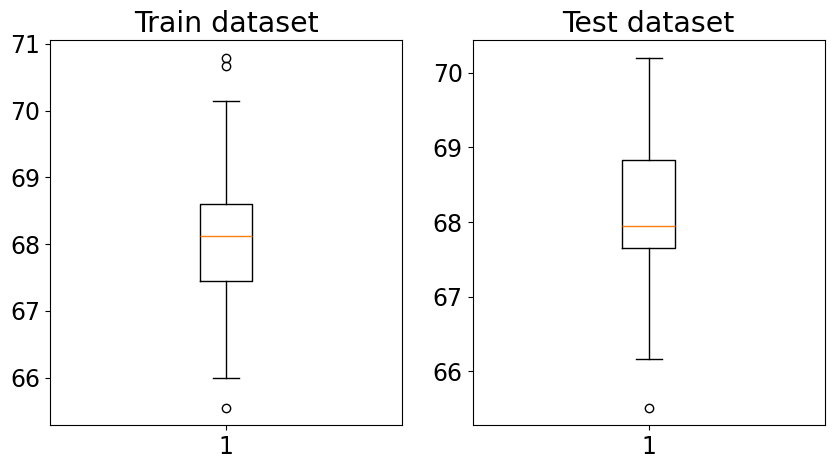

In [9]:
fig = plt.figure(figsize =(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
bp = plt.boxplot(y_train)
ax1.set_title("Train dataset")

ax3 = fig.add_subplot(1, 2, 2)
bp = plt.boxplot(y_test)
ax3.set_title("Test dataset")

plt.show()

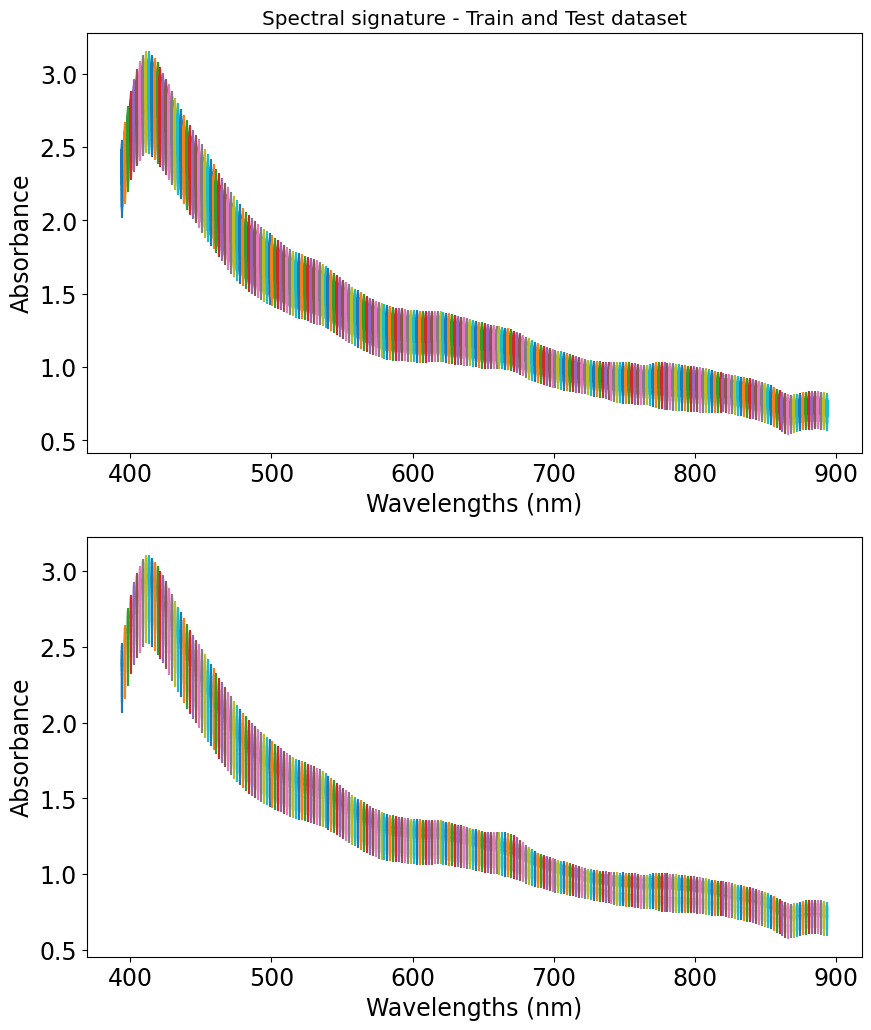

In [10]:
#Ref_train = x_train
#Abs_train = (np.log10(1/Ref_train))

#Abs_train,ref = msc(np.array(x_train))
Abs_train = x_train

#Ref_test = x_test
#Abs_test = (np.log10(1/Ref_test))
#Abs_test = msc(np.array(x_test),ref)[0]
Abs_test = x_test


w1 =[394.35,396.4374,398.5248,400.6122,402.6996,404.787,406.8744,408.9618,411.0492,413.1366,415.224,417.3114,419.3988,421.4862,423.5736,425.661,427.7484,429.8358,431.9232,434.0106,436.098,438.1854,440.2728,442.3602,444.4476,446.535,448.6224,450.7098,452.7972,454.8846,456.972,459.0594,461.1468,463.2342,465.3216,467.409,469.4964,471.5838,473.6712,475.7586,477.846,479.9334,482.0208,484.1082,486.1956,488.283,490.3704,492.4578,494.5452,496.6326,498.72,500.8074,502.8948,504.9822,507.0696,509.157,511.2444,513.3318,515.4192,517.5066,519.594,521.6814,523.7688,525.8562,527.9436,530.031,532.1184,534.2058,536.2932,538.3806,540.468,542.5554,544.6428,546.7302,548.8176,550.905,552.9924,555.0798,557.1672,559.2546,561.342,563.4294,565.5168,567.6042,569.6916,571.779,573.8664,575.9538,578.0412,580.1286,582.216,584.3034,586.3908,588.4782,590.5656,592.653,594.7404,596.8278,598.9152,601.0026,603.09,605.1774,607.2648,609.3522,611.4396,613.527,615.6144,617.7018,619.7892,621.8766,623.964,626.0514,628.1388,630.2262,632.3136,634.401,636.4884,638.5758,640.6632,642.7506,644.838,646.9254,649.0128,651.1002,653.1876,655.275,657.3624,659.4498,661.5372,663.6246,665.712,667.7994,669.8868,671.9742,674.0616,676.149,678.2364,680.3238,682.4112,684.4986,686.586,688.6734,690.7608,692.8482,694.9356,697.023,699.1104,701.1978,703.2852,705.3726,707.46,709.5474,711.6348,713.7222,715.8096,717.897,719.9844,722.0718,724.1592,726.2466,728.334,730.4214,732.5088,734.5962,736.6836,738.771,740.8584,742.9458,745.0332,747.1206,749.208,751.2954,753.3828,755.4702,757.5576,759.645,761.7324,763.8198,765.9072,767.9946,770.082,772.1694,774.2568,776.3442,778.4316,780.519,782.6064,784.6938,786.7812,788.8686,790.956,793.0434,795.1308,797.2182,799.3056,801.393,803.4804,805.5678,807.6552,809.7426,811.83,813.9174,816.0048,818.0922,820.1796,822.267,824.3544,826.4418,828.5292,830.6166,832.704,834.7914,836.8788,838.9662,841.0536,843.141,845.2284,847.3158,849.4032,851.4906,853.578,855.6654,857.7528,859.8402,861.9276,864.015,866.1024,868.1898,870.2772,872.3646,874.452,876.5394,878.6268,880.7142,882.8016,884.889,886.9764,889.0638,891.1512,893.2386]
w2_train=np.matlib.repmat(w1,len_x_train,1)

w2_test=np.matlib.repmat(w1,len_x_test,1)


fig = plt.figure(figsize=(10, 12))

ax1 = fig.add_subplot(2, 1, 1)

with plt.style.context('ggplot'):
    plt.plot(w2_train, Abs_train, label='Absorbancia')
    plt.xlabel("Wavelengths (nm)")
    plt.ylabel("Absorbance")
    plt.title("Spectral signature - Train and Test dataset")

ax3 = fig.add_subplot(2, 1, 2)

with plt.style.context('ggplot'):
    plt.plot(w2_test, Abs_test, label='Absorbancia')
    plt.xlabel("Wavelengths (nm)")
    plt.ylabel("Absorbance")
    #plt.title("Firma Espectral-Data Test")



## 5. PREPROCESAMIENTO: Normalización de datos

In [11]:
transformer = Normalizer().fit(Abs_train)

Abs_train = transformer.transform(Abs_train)
Abs_test = transformer.transform(Abs_test)

## 6. AJUSTE PLS: selección de número de componentes

In [12]:
q2_ac = []
r2_ac = []
r2_s = []

variables=50
r2t=0
xticks= np.arange(1, variables+1)

for n_comp in xticks:
    r2, q2 = optimise_pls_cv(Abs_train, y_train, 10, n_comp)
    print("ajustando modelo a n componentes:",n_comp)


    r2_ac.append(r2)
    r2_s.append(r2-r2t)
    r2t=r2
    q2_ac.append(q2)


ajustando modelo a n componentes: 1
ajustando modelo a n componentes: 2
ajustando modelo a n componentes: 3
ajustando modelo a n componentes: 4
ajustando modelo a n componentes: 5
ajustando modelo a n componentes: 6
ajustando modelo a n componentes: 7
ajustando modelo a n componentes: 8
ajustando modelo a n componentes: 9
ajustando modelo a n componentes: 10
ajustando modelo a n componentes: 11
ajustando modelo a n componentes: 12
ajustando modelo a n componentes: 13
ajustando modelo a n componentes: 14
ajustando modelo a n componentes: 15
ajustando modelo a n componentes: 16
ajustando modelo a n componentes: 17
ajustando modelo a n componentes: 18
ajustando modelo a n componentes: 19
ajustando modelo a n componentes: 20
ajustando modelo a n componentes: 21
ajustando modelo a n componentes: 22
ajustando modelo a n componentes: 23
ajustando modelo a n componentes: 24
ajustando modelo a n componentes: 25
ajustando modelo a n componentes: 26
ajustando modelo a n componentes: 27
ajustando 

componente seleccionada:  50


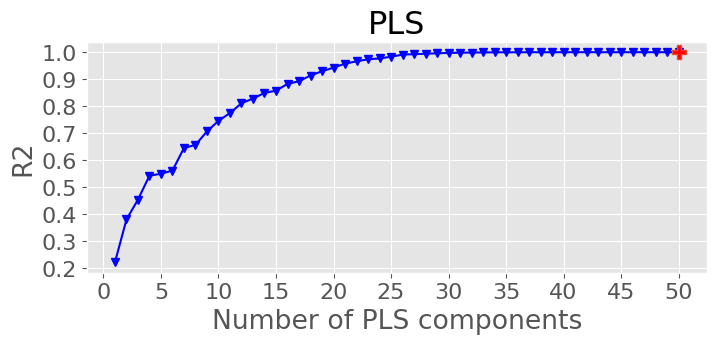

In [13]:
NCOMP=plot_metrics(r2_ac, xticks,'R2', 'max',show=1)

componente seleccionada:  15


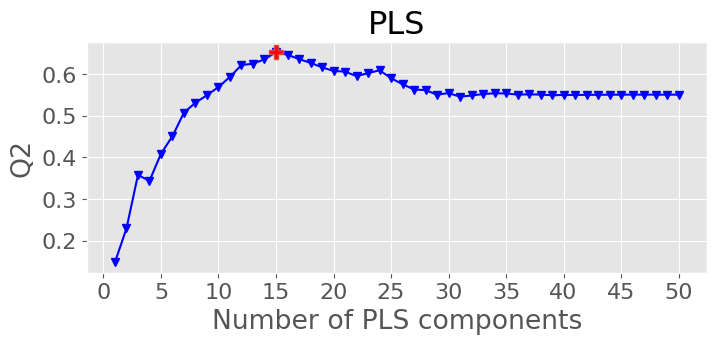

In [14]:
NCOMP=plot_metrics(q2_ac, xticks,'Q2', 'max',show=1)

##7. VALIDACION

In [15]:
pls = PLSRegression(n_components=NCOMP)

pls.fit(Abs_train, y_train)

#TRAIN
y_pred_train=pls.predict(Abs_train, copy=True)

#TEST
y_pred_test=pls.predict(Abs_test, copy=True)

r2 = r2_score(y_train, y_pred_train)*100
r2t = r2_score(y_test, y_pred_test)*100

print('R2-train:{0:.2f}%'.format(r2))
print('R2-test:{0:.2f}%'.format(r2t))

R2-train:85.76%
R2-test:84.67%


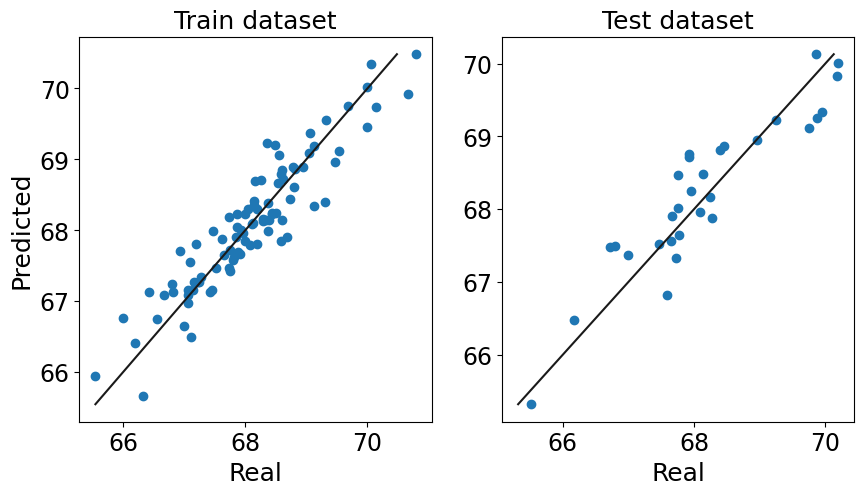

In [16]:
fig = plt.figure(figsize =(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
scatterplot(y_train,y_pred_train,ax1)
ax1.set_title("Train dataset",fontsize=18)
ax1.set_xlabel('Real',fontsize=18)
ax1.set_ylabel('Predicted',fontsize=18)

ax2 = fig.add_subplot(1, 2, 2)
scatterplot(y_test,y_pred_test,ax2)
ax2.set_title("Test dataset",fontsize=18)
ax2.set_xlabel('Real',fontsize=18)

plt.show()

fig.savefig('Fig 6.png', dpi=1200, bbox_inches = 'tight')

In [17]:
print("RMSE train",RMSE(y_train,y_pred_train))
print("RMSE test",RMSE(y_test,y_pred_test))

RMSE train 0.14205590425372525
RMSE test 0.20542045460955385


##8. VIP

In [18]:
w=pls.x_weights_

SSYcum_SST=r2_ac[NCOMP-1]
SSYa_SST=r2_s[0:NCOMP]

i=1

VIP=[]
bandas=240
for i in range(0,bandas):
  VIPi= (bandas*(np.dot((w[i]**2),SSYa_SST)/SSYcum_SST))**0.5
  VIP.append(VIPi)

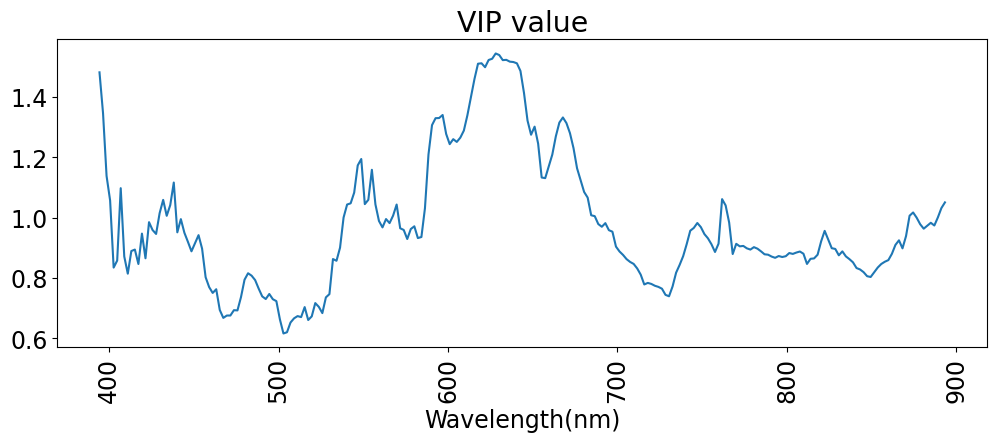

In [19]:

f,ax=plt.subplots(figsize=(12, 4))
ax.plot(labels,VIP)
ax.set_title('VIP value')
ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel("Wavelength(nm)")

f.savefig('Fig 7.png', dpi=1200, bbox_inches = 'tight')

SELECTION VIA VIP

In [20]:
print('R2-train:{0:.2f}%'.format(r2))
print('R2-test:{0:.2f}%'.format(r2t))

R2-train:85.76%
R2-test:84.67%


In [21]:
VIP_value=np.arange(0.5, 1.35,0.05)

VIP=np.array(VIP)

Q2_record=[]
R2_record=[]
R2_test_record=[]
NCOMP_selected_record=[]

for VIP_value_i in VIP_value:



    index_VIP = np.where(VIP >= VIP_value_i)

    Abs_train_filter=np.squeeze(Abs_train[:,index_VIP])
    Abs_test_filter=np.squeeze(Abs_test[:,index_VIP])

    q2_ac = []
    r2_ac = []
    r2_s = []

    #variables=np.min([50, np.size(Abs_train_filter,1)])
    #r2t=0
    #xticks= np.arange(1, variables+1)

    #for n_comp in xticks:
    #    r2, q2 = optimise_pls_cv(Abs_train_filter, y_train,10, n_comp)

    #    r2_ac.append(r2)
    #    r2_s.append(r2-r2t)
    #    r2t=r2
    #    q2_ac.append(q2)

    #NCOMP=xticks[np.argmax(q2_ac)]

    pls = PLSRegression(n_components=NCOMP)

    r2, q2 = optimise_pls_cv(Abs_train_filter, y_train,10, NCOMP)

    pls.fit(Abs_train_filter, y_train)

    #TRAIN
    #y_pred_train=pls.predict(Abs_train_filter, copy=True)
    y_pred_test=pls.predict(Abs_test_filter, copy=True)

    #r2 = r2_score(y_train, y_pred_train)*100
    r2_t = r2_score(y_test, y_pred_test)*100

    Q2_record.append(q2*100)
    R2_record.append(r2*100)
    R2_test_record.append(r2_t)
    NCOMP_selected_record.append(NCOMP)
    print('number of bands:{0:.0f}'.format(np.size(Abs_train_filter,1)))
    print('VIP-value:{0:.2f}'.format(VIP_value_i))
    print('Q2:{0:.2f}%'.format(q2*100))
    print('R2-train:{0:.2f}%'.format(r2*100))
    print('R2-test:{0:.2f}%'.format(r2_t))
    print('Components:{0:.0f}'.format(NCOMP))
    print('----------------------------------------------------------')


number of bands:240
VIP-value:0.50
Q2:65.24%
R2-train:85.76%
R2-test:84.67%
Components:15
----------------------------------------------------------
number of bands:240
VIP-value:0.55
Q2:65.24%
R2-train:85.76%
R2-test:84.67%
Components:15
----------------------------------------------------------
number of bands:240
VIP-value:0.60
Q2:65.24%
R2-train:85.76%
R2-test:84.67%
Components:15
----------------------------------------------------------
number of bands:238
VIP-value:0.65
Q2:64.93%
R2-train:85.74%
R2-test:84.67%
Components:15
----------------------------------------------------------
number of bands:224
VIP-value:0.70
Q2:65.49%
R2-train:86.16%
R2-test:83.45%
Components:15
----------------------------------------------------------
number of bands:211
VIP-value:0.75
Q2:61.14%
R2-train:86.44%
R2-test:87.47%
Components:15
----------------------------------------------------------
number of bands:198
VIP-value:0.80
Q2:62.18%
R2-train:85.88%
R2-test:87.08%
Components:15
----------------

selected VIP:0.95


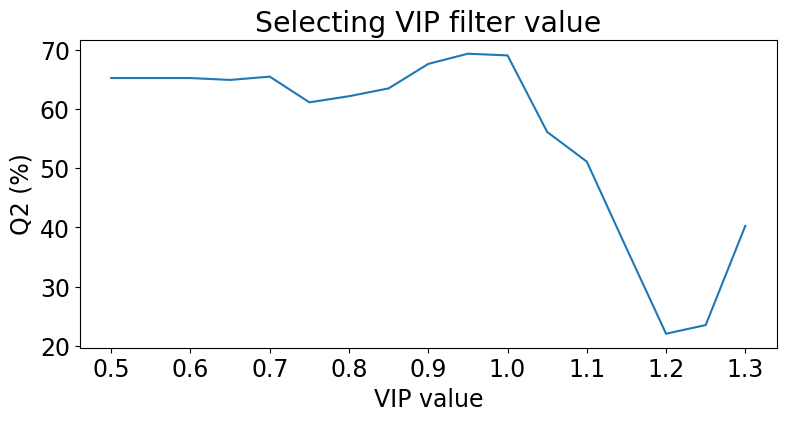

In [22]:
#Q2_record
#R2_record
#R2_test_record

objetive=Q2_record

f,ax=plt.subplots(figsize=(9, 4))
ax.plot(VIP_value,objetive)
ax.set_title('Selecting VIP filter value')
ax.set_xlabel('VIP value')
ax.set_ylabel('Q2 (%)')
ax.xaxis.set_tick_params(rotation=0)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))

idx=np.argmax(objetive)

print('selected VIP:{0:.2f}'.format(VIP_value[idx]))

f.savefig('Fig 8.png', dpi=1200, bbox_inches = 'tight')

In [23]:
NCOMP=NCOMP_selected_record[idx]

index_VIP = np.where(VIP >= VIP_value[idx])

Abs_train_filter=np.squeeze(Abs_train[:,index_VIP])
Abs_test_filter=np.squeeze(Abs_test[:,index_VIP])

pls = PLSRegression(n_components=NCOMP)

pls.fit(Abs_train_filter, y_train)

#TRAIN
y_pred_train=pls.predict(Abs_train_filter, copy=True)


#TEST
y_pred_test=pls.predict(Abs_test_filter, copy=True)

r2 = r2_score(y_train, y_pred_train)*100
r2t = r2_score(y_test, y_pred_test)*100


print('R2-train:{0:.2f}%'.format(r2))
print('R2-test:{0:.2f}%'.format(r2t))
print('number of bands:{0:.0f}'.format(np.size(Abs_train_filter,1)))

R2-train:85.44%
R2-test:87.83%
number of bands:107


In [32]:
# Calculate prediction errors
train_errors = y_train.values.flatten() - y_pred_train.flatten()
test_errors = y_test.values.flatten() - y_pred_test.flatten()

# Create a DataFrame for the errors
errors_df = pd.DataFrame({'Error': np.concatenate([train_errors, test_errors]),
                         'Dataset': ['Train'] * len(train_errors) + ['Test'] * len(test_errors)})
print(errors_df)
# Save the DataFrame to an Excel file
errors_df.to_excel('train_test_errors.xlsx', index=False)

        Error Dataset
0    0.424402   Train
1   -0.100486   Train
2   -0.274597   Train
3   -0.326352   Train
4    0.103317   Train
..        ...     ...
117 -0.373613    Test
118 -0.597752    Test
119  0.369349    Test
120 -0.050659    Test
121 -0.285236    Test

[122 rows x 2 columns]


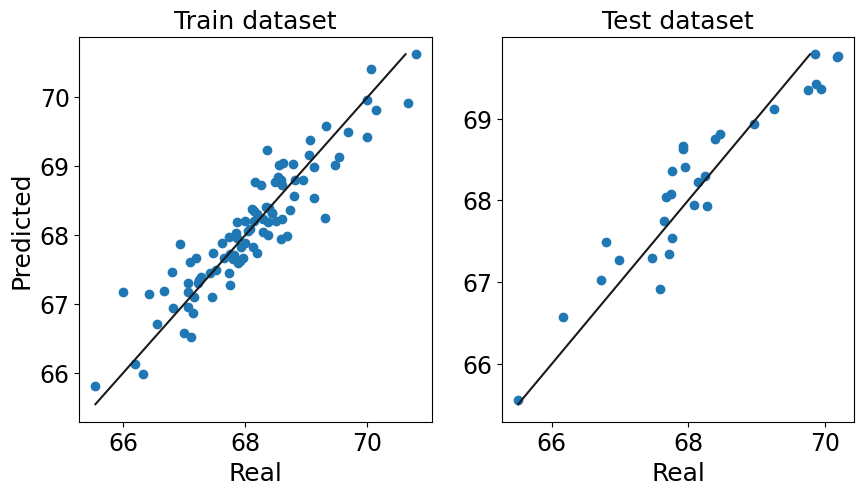

In [24]:
fig = plt.figure(figsize =(10, 5))

ax1 = fig.add_subplot(1, 2, 1)
scatterplot(y_train,y_pred_train,ax1)
ax1.set_title("Train dataset",fontsize=18)
ax1.set_xlabel('Real',fontsize=18)
ax1.set_ylabel('Predicted',fontsize=18)

ax2 = fig.add_subplot(1, 2, 2)
scatterplot(y_test,y_pred_test,ax2)
ax2.set_title("Test dataset",fontsize=18)
ax2.set_xlabel('Real',fontsize=18)

plt.show()

fig.savefig('Fig 10.png', dpi=1200, bbox_inches = 'tight')

In [25]:
print("RMSE train",RMSE(y_train,y_pred_train))
print("RMSE test",RMSE(y_test,y_pred_test))

record = y_test.assign(Predicted=y_pred_test)

record.to_excel('record-PLS-VIP.xlsx', index=False)

RMSE train 0.1452017234898359
RMSE test 0.1631214928039094


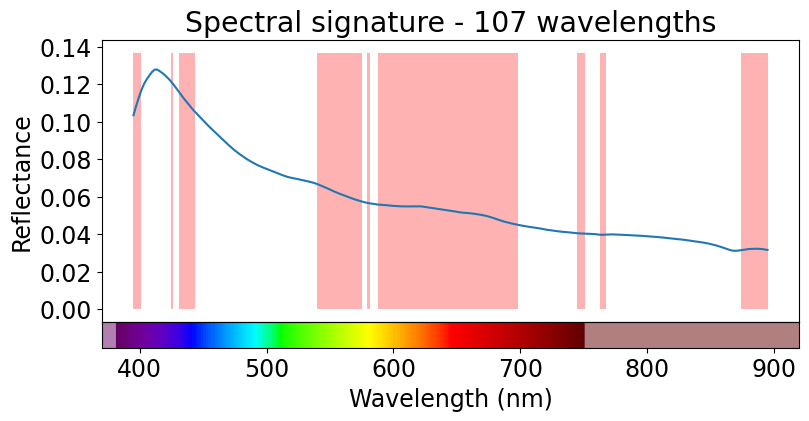

In [26]:
margin=0.005
fig, ax = plt.subplots(2, figsize=(9,4), height_ratios=[11, 1])
plt.subplots_adjust(wspace=0, hspace=0)

ax[0].plot(w1, np.mean(Abs_train,0))
ax[0].get_yaxis().set_visible(True)
ax[0].get_xaxis().set_visible(False)
ax[0].set_ylabel("Reflectance")
ax[0].yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax[0].set_title("Spectral signature - {0:.0f} wavelengths".format(np.size(Abs_train_filter,1)))

ax[0].fill_between(w1,np.max(Abs_train)+margin, where=VIP >= VIP_value[idx], facecolor='red', alpha=0.3)

print_wavelength(ax[1])

fig.savefig('Fig 9.png', dpi=1200, bbox_inches = 'tight')